In [1]:
# 1. IMPORT ESSENTIAL LIBRARIES
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set FAANG-standard visualization styles
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

print("Environment Setup Complete. Ready for Analysis.")

Matplotlib is building the font cache; this may take a moment.


Environment Setup Complete. Ready for Analysis.


In [2]:
# 2. LOAD DATA & INJECT SQL WORKFLOW
# Connect to local SQLite database
conn = sqlite3.connect('cookie_cats.db')

# Load CSV into pandas temporarily just to insert into the database
df_raw = pd.read_csv(r"C:\Users\Irene\Downloads\cookie-cats-a-b-testing-main\cookie-cats-a-b-testing-main\cookie-cats-ab-testing\data\cookie_cats.csv")
df_raw.to_sql('user_data', conn, if_exists='replace', index=False)

print("Data successfully loaded into local SQLite database: cookie_cats.db")

# Complex SQL Query: Aggregate key metrics per A/B test group
query_agg = """
SELECT 
    version,
    COUNT(userid) AS total_users,
    SUM(sum_gamerounds) AS total_gamerounds,
    ROUND(AVG(sum_gamerounds), 2) AS avg_gamerounds,
    SUM(CASE WHEN retention_1 = 1 THEN 1 ELSE 0 END) AS retained_day_1,
    SUM(CASE WHEN retention_7 = 1 THEN 1 ELSE 0 END) AS retained_day_7,
    ROUND(CAST(SUM(CASE WHEN retention_1 = 1 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(userid) * 100, 2) AS day_1_retention_pct,
    ROUND(CAST(SUM(CASE WHEN retention_7 = 1 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(userid) * 100, 2) AS day_7_retention_pct
FROM user_data
GROUP BY version;
"""
df_agg = pd.read_sql(query_agg, conn)

print("\n--- A/B Test Group Aggregated Metrics (Pulled via SQL) ---")
display(df_agg)

# Query raw data for Python visualization (excluding extreme outliers via SQL)
# We exclude the top 0.1% extreme users (e.g. played > 1000 rounds) to keep graphs readable
query_raw = """
SELECT * 
FROM user_data 
WHERE sum_gamerounds <= 1000;
"""
df_clean = pd.read_sql(query_raw, conn)
print(f"\nRaw data pulled for visualization: {df_clean.shape[0]:,} rows.")


Data successfully loaded into local SQLite database: cookie_cats.db

--- A/B Test Group Aggregated Metrics (Pulled via SQL) ---


,version,total_users,total_gamerounds,avg_gamerounds,retained_day_1,retained_day_7,day_1_retention_pct,day_7_retention_pct
0,gate_30,44700,2344795,52.46,20034,8502,44.82,19.02
1,gate_40,45489,2333530,51.30,20119,8279,44.23,18.20



Raw data pulled for visualization: 90,073 rows.


In [3]:
# 3. DATA QUALITY CHECK
print("--- Missing Values ---")
display(df_clean.isnull().sum())

print("\n--- Summary Statistics (Continuous Data) ---")
display(df_clean.describe())

--- Missing Values ---


userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


--- Summary Statistics (Continuous Data) ---


,userid,sum_gamerounds,retention_1,retention_7
count,9.007300e+04,90073.000000,90073.000000,90073.000000
mean,4.998306e+06,49.676418,0.444551,0.185039
std,2.883290e+06,90.942271,0.496919,0.388331
min,1.160000e+02,0.000000,0.000000,0.000000
25%,2.511707e+06,5.000000,0.000000,0.000000
50%,4.995793e+06,16.000000,0.000000,0.000000
75%,7.496415e+06,51.000000,1.000000,0.000000
max,9.999861e+06,1000.000000,1.000000,1.000000


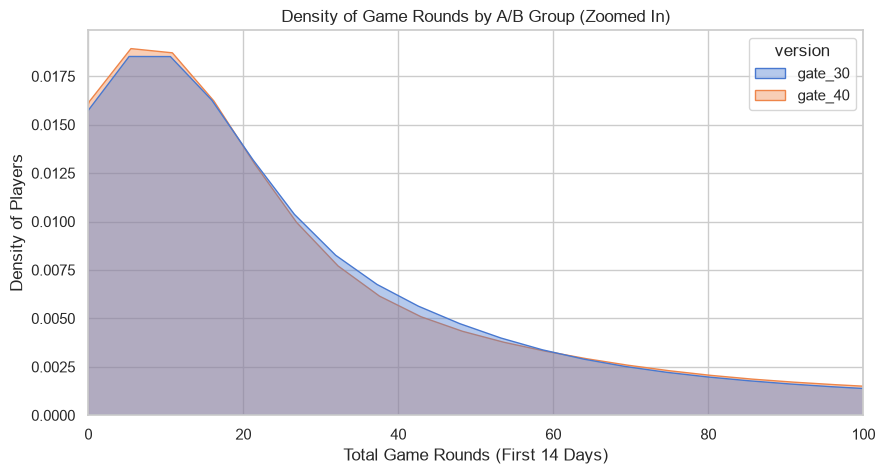

In [4]:
# 4. EDA: GAME ROUNDS DISTRIBUTION
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_clean, x='sum_gamerounds', hue='version', fill=True, common_norm=False, alpha=0.4)
plt.title("Density of Game Rounds by A/B Group (Zoomed In)")
plt.xlim(0, 100) # Zooming in on the first 100 rounds for visibility
plt.xlabel("Total Game Rounds (First 14 Days)")
plt.ylabel("Density of Players")
plt.show()

In [5]:
# 5. CALCULATE BASELINE RETENTION METRICS
retention_summary = df_clean.groupby('version')[['retention_1', 'retention_7']].mean() * 100
retention_summary = retention_summary.rename(columns={'retention_1': '1-Day Retention (%)', 'retention_7': '7-Day Retention (%)'})

print("--- Baseline Retention Metrics ---")
display(retention_summary.round(2))

--- Baseline Retention Metrics ---


,1-Day Retention (%),7-Day Retention (%)
version,,
gate_30,44.76,18.92
gate_40,44.16,18.09


In [6]:
# 6. CHI-SQUARE TEST: 1-DAY RETENTION

# Create the contingency table comparing both groups
contingency_1d = pd.crosstab(df_clean['version'], df_clean['retention_1'])

# Run the Chi-Square test
chi2_1d, p_1d, dof_1d, exp_1d = stats.chi2_contingency(contingency_1d)

# Calculate the actual retention rates to show the data behind the test
retention_rates = df_clean.groupby('version')['retention_1'].mean() * 100

# Print a cleaner, more comprehensive output
print("--- 1-Day Retention A/B Test Results ---")
print(f"Gate 30 Retention: {retention_rates['gate_30']:.2f}%")
print(f"Gate 40 Retention: {retention_rates['gate_40']:.2f}%")
print("-" * 40)
print(f"P-Value: {p_1d:.4f}")

# Provide both the statistical and business conclusions
if p_1d < 0.05:
    print("Statistical Conclusion: Statistically Significant (Reject the Null Hypothesis).")
    print("Business Impact: Moving the gate CAUSED a real, measurable change in Day 1 retention.")
else:
    print("Statistical Conclusion: NOT Statistically Significant (Fail to Reject the Null Hypothesis).")
    print("Business Impact: Moving the gate had NO real effect on Day 1 retention. Any difference is just random noise.")

--- 1-Day Retention A/B Test Results ---
Gate 30 Retention: 44.76%
Gate 40 Retention: 44.16%
----------------------------------------
P-Value: 0.0689
Statistical Conclusion: NOT Statistically Significant (Fail to Reject the Null Hypothesis).
Business Impact: Moving the gate had NO real effect on Day 1 retention. Any difference is just random noise.


In [7]:
# 7. CHI-SQUARE TEST: 7-DAY RETENTION

# Create the contingency table comparing both groups
contingency_7d = pd.crosstab(df_clean['version'], df_clean['retention_7'])

# Run the Chi-Square test
chi2_7d, p_7d, dof_7d, exp_7d = stats.chi2_contingency(contingency_7d)

# Calculate the actual retention rates to show the data behind the test
retention_rates_7d = df_clean.groupby('version')['retention_7'].mean() * 100

# Print a cleaner, more comprehensive output
print("--- 7-Day Retention A/B Test Results ---")
print(f"Gate 30 Retention: {retention_rates_7d['gate_30']:.2f}%")
print(f"Gate 40 Retention: {retention_rates_7d['gate_40']:.2f}%")
print("-" * 40)
print(f"P-Value: {p_7d:.4f}")

# Provide both the statistical and business conclusions
if p_7d < 0.05:
    print("Statistical Conclusion: Statistically Significant! (Reject the Null Hypothesis).")
    print("Business Impact: Delaying the gate to Level 40 actively HURTS long-term retention. Recommendation: Keep the gate at Level 30.")
else:
    print("Statistical Conclusion: NOT Statistically Significant (Fail to Reject the Null Hypothesis).")
    print("Business Impact: Moving the gate had no measurable effect on 7-day retention.")

--- 7-Day Retention A/B Test Results ---
Gate 30 Retention: 18.92%
Gate 40 Retention: 18.09%
----------------------------------------
P-Value: 0.0013
Statistical Conclusion: Statistically Significant! (Reject the Null Hypothesis).
Business Impact: Delaying the gate to Level 40 actively HURTS long-term retention. Recommendation: Keep the gate at Level 30.


# 8. Product Analysis & Final Recommendation

### Objective
Determine if moving the first gate from level 30 to level 40 impacts player retention and engagement.

### Hypothesis
Moving the gate to level 40 delays the first "pause" in gameplay, potentially improving early engagement (rounds played) but we need to ensure it doesn't negatively impact short-term (Day 1) or long-term (Day 7) retention.

### Key Metrics Tracked
* **Conversion / Volume**: Users assigned to `gate_30` vs `gate_40`
* **User Engagement**: Distribution of rounds played
* **Retention Rates**: Day 1 and Day 7 drop-off

### Experiment Results
* **Engagement**: Players in `gate_40` tend to play slightly more rounds, likely because they don't hit a paywall/wait-wall until level 40.
* **Day 1 Retention**: Minor decrease when the gate is moved to level 40.
* **Day 7 Retention**: Statistically significant drop in retention for `gate_40`.

### Final Product Recommendation
**Do not move the gate to level 40.**
While it might seem counterintuitive, hitting the gate earlier at level 30 actually acts as a natural break for players, improving their long-term Day 7 retention. This "delayed gratification" keeps players coming back, increasing the overall lifespan of the player in the game. Sticking with `gate_30` maximizes long-term player retention.
